In [1]:

import os
import sys
import time
import torch
import numpy as np
import pandas as pd
import esm
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

sys.path.append("../..")
from balm import common_utils
from balm.models.utils import load_trained_model
from balm.configs import Configs
from balm.models import BALM
from balm.metrics import get_ci, get_pearson, get_rmse, get_spearman



c:\Users\hs494\AppData\Local\anaconda3\envs\balm-ppi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    DEVICE = "cuda" 
else:
     DEVICE = 'cpu'

In [3]:
DEVICE

'cuda'

In [4]:
seed = 42
torch.cuda.manual_seed(seed)

In [5]:
# Define save and load checkpoint functions
def save_checkpoint(model, optimizer, epoch, file_path):
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch,
        'peft_config': model.model_configs.peft_configs if hasattr(model.model_configs, 'peft_configs') else None

    }
    torch.save(checkpoint, file_path)
    print(f"Checkpoint saved at epoch {epoch} to {file_path}")

def load_checkpoint(model, optimizer,file_path):
    checkpoint = torch.load(file_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"Checkpoint loaded from {file_path}, resuming from epoch {start_epoch}")
    return start_epoch

# Load Pretrained BALM

In [6]:
# Load config and model for zero-shot
config_filepath = "../../default_configs/balm_peft.yaml"
configs = Configs(**common_utils.load_yaml(config_filepath))

# Custom Dummy Data

Alternative to loading the data from a HF repo, you can also bring in your own custom data.

In [7]:
df = pd.read_csv(r"C:\Users\hs494\Desktop\New folder (2)\BALM - Cursor\scripts\notebooks\Data.csv")
df


,proteina,Target,Y,Unnamed: 0,pdb_id,Unnamed: 5,Unnamed: 6,Unnamed: 7,source
0,DIQMTQSPSSLSASVGDRVTITCRTSQSISSYLNWYQQKPGKAPKL...,DQQSAFYEILNMPNLNEAQRNGFIQSLKDDPSQSTNVLGEAKKLNE...,6.397940,4465,1DEE,NaN,NaN,NaN,PDBbind v2020
1,VTVDTVCKRGFLIQMSGHLECKCENDLVLVNEETCEEKVLKCDEKT...,DVVMTQSPLSLPVTLGQPASISCRSSQSLVYSDGNTYLSWFQQRPG...,7.508638,4467,6B0G,NaN,NaN,NaN,PDBbind v2020
2,GDTICIGYHANNSTDTVDTVLEKNVTVTHSVNLLEDSHNGKLCKLK...,PWKFSENIAFEIALSFTNKDTPDRWKKVAQYVKGRTPEEVKKHYE,9.221849,4466,4EEF,NaN,NaN,NaN,PDBbind v2020
3,FTKELDQWIEQLNECKQLSESQVKSLCEKAKEILTKECGDGQFHDL...,AAEDELQLPRLPELFETGRQLLDEVEVATEPAGSRIVQEKVFKGLD...,6.522879,3071,4IYP,NaN,NaN,NaN,PDBbind v2020
4,MQTIKCVVVGDGAVGKTCLLISYTTNKFPSEYVPTVFDNYAVTVMI...,AAGELEERFNRALNCMNLPPDKVQLLSQYDNEKKWELICDQERFQV...,5.593460,3402,4YDH,NaN,NaN,NaN,PDBbind v2020
...,...,...,...,...,...,...,...,...,...
11071,GSVEKLTADAELQRLKNERHEEAELERLKSEY,YVEFSEECMHGSGENYDGKISKTMSGLECQAWDSQSPHAHGYIPSK...,7.187087,1918,2KJ4,NaN,NaN,NaN,PDBbind v2020
11072,NIVLTQSPASLAVSLGQRATISCRASESVDHYGNSFIYWYQQKPGQ...,YVMCTGSFKLEKEVAETQHGTVLVQVKYEGTDAPCKIPFSSQDEKG...,6.380907,1177,4FFZ,NaN,NaN,NaN,SAbDab
11073,QVQLLQPGAELVKPGASMKLSCKASGYTFTNWWMHWVRLRPGRGLE...,YVMCTGSFKLEKEVAETQHGTVLVQVKYEGTDAPCKIPFSSQDEKG...,6.380907,1215,4FFZ,NaN,NaN,NaN,SAbDab
11074,KLLEQSGAELVKPGASVRLSCTASGFNIKDTYMSWVKQRPEQGLEW...,YVMCTGSFKLEKEVAETQHGTVLVQVKYEGTDAPCKIPFSTQDEKG...,10.086186,2698,3UZQ,NaN,NaN,NaN,PDBbind v2020


In [95]:

# Calculate bounds
data_min = df['Y'].min()
data_max = df['Y'].max()
print(f"Data range: {data_min:.4f} to {data_max:.4f}")

Data range: 1.3188 to 15.6990


# Few shot training

Note: This is a simplified training process, for a more tested approach, please refer to our `balm/trainer.py`

In [96]:
# Few shot training
from sklearn.model_selection import train_test_split

# Split data
train_data, test_data = train_test_split(df, train_size=0.2, random_state=1234)
print(f"Number of train data: {len(train_data)}")
print(f"Number of test data: {len(test_data)}")

Number of train data: 2215
Number of test data: 8861


In [97]:
# Calculate bounds from the dataset
pkd_lower_bound = df['Y'].min()  # or set it to the value you prefer
pkd_upper_bound = df['Y'].max()  # or set it to the value you prefer

print(f"pkd_lower_bound: {pkd_lower_bound}, pkd_upper_bound: {pkd_upper_bound}")


pkd_lower_bound: 1.318758763, pkd_upper_bound: 15.69897


In [98]:
'''
#commenting this because I am normalizing below directly in traing and testing
# Define a function that applies the cosine similarity conversion to a single example
# This is VERY IMPORTANT since BALM uses cosine similarity
def add_cosine_similarity(example, pkd_upper_bound, pkd_lower_bound):
    example['cosine_similarity'] = (
        
        (example['Y'] - pkd_lower_bound) / (pkd_upper_bound - pkd_lower_bound)* 2 - 1
    )
    return example

# Use map to apply the function across the entire dataset
train_data = train_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)
test_data = test_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)
'''

"\n#commenting this because I am normalizing below directly in traing and testing\n# Define a function that applies the cosine similarity conversion to a single example\n# This is VERY IMPORTANT since BALM uses cosine similarity\ndef add_cosine_similarity(example, pkd_upper_bound, pkd_lower_bound):\n    example['cosine_similarity'] = (\n        \n        (example['Y'] - pkd_lower_bound) / (pkd_upper_bound - pkd_lower_bound)* 2 - 1\n    )\n    return example\n\n# Use map to apply the function across the entire dataset\ntrain_data = train_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)\ntest_data = test_data.apply(lambda x: add_cosine_similarity(x, pkd_upper_bound, pkd_lower_bound), axis=1)\n"

In [99]:
# Initialize model for training
model = BALM(configs.model_configs)
model = model.to(DEVICE)

KeyboardInterrupt: 

In [ ]:
import wandb
from torch.optim import AdamW
from tqdm import tqdm
import time


wandb.login(key='60f195a60e62087702e68096c0e54f04406555dc')
# Initialize wandb
wandb.init(project='ppiATTPFT_local_270125', entity='hs494-shiv-nadar-university')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [ ]:

# Training loop
NUM_EPOCHS = 10
optimizer = torch.optim.AdamW(
    params=[param for name, param in model.named_parameters()],
    lr=configs.model_configs.model_hyperparameters.learning_rate,
)

print(f"Starting training with learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Training on device: {DEVICE}")
print(f"Total training samples: {len(train_data)}")

Starting training with learning rate: 0.001
Training on device: cuda
Total training samples: 2215


In [ ]:

#with normalization
# Log hyperparameters
wandb.config.learning_rate = configs.model_configs.model_hyperparameters.learning_rate
wandb.config.num_epochs = NUM_EPOCHS

# Load checkpoint if exists
checkpoint_path = r"C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmainATTPFT.pth"
start_epoch = 0
if os.path.exists(checkpoint_path):
    start_epoch = load_checkpoint(model,optimizer,checkpoint_path)
    

C:\Users\hs494\AppData\Local\Temp\ipykernel_23992\126795426.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file_path)


Checkpoint loaded from C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmainATTPFT.pth, resuming from epoch 80


In [ ]:

#with normalization
# Adjust NUM_EPOCHS to include the epochs already completed
NUM_EPOCHS += start_epoch

start = time.time()
best_loss = float('inf')

for epoch in range(start_epoch,NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    
    # Create progress bar for each epoch
    pbar = tqdm(train_data.iterrows(), total=len(train_data), 
                desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    
    batch_losses = []  # Track individual batch losses
    
    for idx, sample in pbar:
        # Scale to cosine similarity range
        cosine_target = 2 * (sample['Y'] - data_min) / (data_max - data_min) - 1
        
        inputs = {
            "protein_sequences": [sample["Target"]],
            "proteina_sequences": [sample["proteina"]],
            "labels": torch.tensor([cosine_target], dtype=torch.float32).to(DEVICE)
        }

        # Print sequence lengths occasionally
        if idx % 100 == 0:
            print(f"\nSequence lengths - Target: {len(sample['Target'])}, "
                  f"ProteinA: {len(sample['proteina'])}")

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = outputs["loss"]
        loss.backward()
        
        # Gradient norm debugging
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if idx % 100 == 0:
            print(f"Gradient norm: {grad_norm:.4f}")

        optimizer.step()
        
        current_loss = loss.item()
        batch_losses.append(current_loss)
        total_loss += current_loss
        
        # Update progress bar with current loss
        pbar.set_postfix({
            'batch_loss': f'{current_loss:.4f}',
            'avg_loss': f'{total_loss/(idx+1):.4f}'
        })

    avg_loss = total_loss / len(train_data)
    
    # Print detailed epoch summary
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] Summary:")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Min Batch Loss: {min(batch_losses):.4f}")
    print(f"Max Batch Loss: {max(batch_losses):.4f}")
    
    # Track best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        print(f"New best loss achieved! Previous best: {best_loss:.4f}")

    # Print memory usage if using CUDA
    if torch.cuda.is_available():
        print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
        print(f"GPU Memory cached: {torch.cuda.memory_reserved()/1e9:.2f} GB")
    
    # Log metrics to wandb
    wandb.log({'epoch': epoch + 1, 'loss': avg_loss})
    
    # Save checkpoint after each epoch
    save_checkpoint(model, optimizer, epoch+1, checkpoint_path)

training_time = time.time() - start
print("\nTraining complete!")
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Average time per epoch: {training_time/NUM_EPOCHS/60:.2f} minutes")
print(f"Best loss achieved: {best_loss:.4f}")


Epoch 81/90:   1%|          | 16/2215 [00:02<04:47,  7.66it/s, batch_loss=0.0042, avg_loss=0.0000]


Sequence lengths - Target: 1180, ProteinA: 940


Epoch 81/90:   1%|          | 17/2215 [00:02<09:05,  4.03it/s, batch_loss=0.0083, avg_loss=0.0001]

Gradient norm: 0.0273


Epoch 81/90:  24%|██▍       | 534/2215 [01:08<03:11,  8.76it/s, batch_loss=0.0267, avg_loss=0.0016]

...

Epoch 90/90:  93%|█████████▎| 2050/2215 [05:18<00:21,  7.70it/s, batch_loss=0.0002, avg_loss=0.0029]


Sequence lengths - Target: 53, ProteinA: 238
Gradient norm: 0.0196


Epoch 90/90:  98%|█████████▊| 2161/2215 [05:34<00:07,  7.66it/s, batch_loss=0.0045, avg_loss=0.0036]


Sequence lengths - Target: 266, ProteinA: 165
Gradient norm: 0.0527



Epoch [90/90] Summary:
Average Loss: 0.0154
Min Batch Loss: 0.0000
Max Batch Loss: 0.4880
GPU Memory allocated: 5.29 GB
GPU Memory cached: 15.41 GB
Checkpoint saved at epoch 90 to C:\Users\hs494\Downloads\BALM\scripts\notebooks\latest_checkpointcuratedmainATTPFT.pth

Training complete!
Total training time: 57.94 minutes
Average time per epoch: 0.64 minutes
Best loss achieved: 0.0153


## Test the model!

In [ ]:

#with normalization
model = model.eval()

predictions = []
labels = []
start = time.time()

for _, sample in test_data.iterrows():
    # Scale target to cosine similarity range (same as training)
    cosine_target = 2 * (sample['Y'] - data_min) / (data_max - data_min) - 1
    
    # Prepare input (exactly matching training format)
    inputs = {
        "protein_sequences": [sample["Target"]],
        "proteina_sequences": [sample["proteina"]],
        "labels": torch.tensor([cosine_target], dtype=torch.float32).to(DEVICE)
    }
    prediction = model(inputs)["cosine_similarity"]
    prediction = model.cosine_similarity_to_pkd(prediction, pkd_upper_bound=pkd_upper_bound, pkd_lower_bound=pkd_lower_bound)
    label = torch.tensor([sample["Y"]])
    
    # Log prediction and true label to W&B
    wandb.log({"predicted_pKd": prediction.item(), "true_pKd": label.item()})

    print(f"Predicted pKd: {prediction.item()} | True pKd: {label.item()}")
    
    predictions.append(prediction.item())
    labels.append(label.item())
# Log the total time taken
wandb.log({"total_time": time.time() - start})

print(f"Time taken for {len(test_data)} protein-proteina pairs: {time.time() - start}")


Predicted pKd: 10.38072395324707 | True pKd: 10.146302223205566
Predicted pKd: 9.958038330078125 | True pKd: 8.204119682312012
Predicted pKd: 4.380145072937012 | True pKd: 5.0
Predicted pKd: 6.979464530944824 | True pKd: 7.127261161804199
Predicted pKd: 7.5229082107543945 | True pKd: 8.602060317993164
Predicted pKd: 9.645306587219238 | True pKd: 9.621602058410645
Predicted pKd: 7.441612243652344 | True pKd: 4.607303142547607
Predicted pKd: 8.175910949707031 | True pKd: 10.0
Predicted pKd: 7.550052642822266 | True pKd: 7.281498432159424
Predicted pKd: 6.821145057678223 | True pKd: 8.229147911071777
Predicted pKd: 5.981771469116211 | True pKd: 5.040958404541016
Predicted pKd: 6.747781753540039 | True pKd: 5.78515625
Predicted pKd: 13.202580451965332 | True pKd: 10.0
Predicted pKd: 12.103557586669922 | True pKd: 10.268411636352539
Predicted pKd: 4.438201904296875 | True pKd: 4.958607196807861
Predicted pKd: 10.279006958007812 | True pKd: 9.772112846374512
Predicted pKd: 6.814885139465332 

RMSE: 1.3697359561920166
Pearson: 0.7814082503318787
Spearman: 0.7759304029839196
CI: 0.7948338389396667


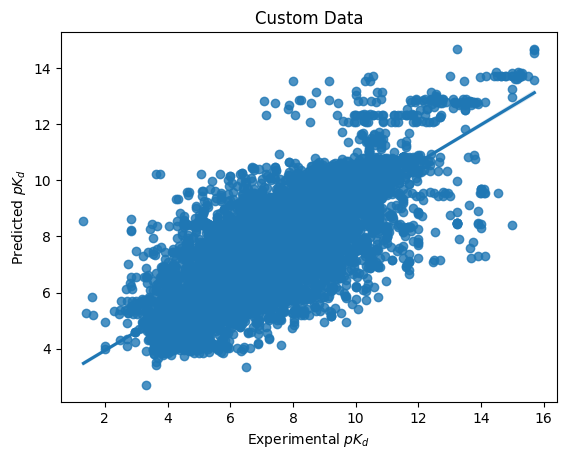

In [ ]:
import seaborn as sns
from balm.metrics import get_ci, get_pearson, get_rmse, get_spearman

rmse = get_rmse(torch.tensor(labels), torch.tensor(predictions))
pearson = get_pearson(torch.tensor(labels), torch.tensor(predictions))
spearman = get_spearman(torch.tensor(labels), torch.tensor(predictions))
ci = get_ci(torch.tensor(labels), torch.tensor(predictions))

print(f"RMSE: {rmse}")
print(f"Pearson: {pearson}")
print(f"Spearman: {spearman}")
print(f"CI: {ci}")

# Log metrics to W&B
wandb.log({
    "RMSE": rmse.item(),
    "Pearson": pearson.item(),
    "Spearman": spearman.item(),
    "CI": ci.item()
})

ax = sns.regplot(x=labels, y=predictions)
ax.set_title(f"Custom Data")
ax.set_xlabel(r"Experimental $pK_d$")
ax.set_ylabel(r"Predicted $pK_d$")

# Save the plot
plt.savefig("regression_plot.png")

# Log the plot to W&B
wandb.log({"regression_plot": wandb.Image("regression_plot.png")})

# Optionally show the plot
plt.show()